# BiLSTM Training mit Similarity-Filter

Dieses Notebook ermöglicht das Training eines BiLSTM-Klassifikators für Normales vs. Einfaches Deutsch. 
Der Datensatz kann basierend auf der semantischen Ähnlichkeit (Similarity) der Artikelpaare gefiltert werden.

In [1]:
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import spacy
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguration
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8  # Mindest-Ähnlichkeit
MAX_SIM = 0.98 # Maximal-Ähnlichkeit

MAX_SEQ_LEN = 100
MIN_SENT_LEN = 3
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Daten laden und filtern

In [2]:
def load_and_filter_data(csv_path, min_sim, max_sim):
    print(f"Lade Daten von {csv_path}...")
    df = pd.read_csv(csv_path)
    
    mask = (df["semantic_similarity_8192"] >= min_sim) & (df["semantic_similarity_8192"] <= max_sim)
    df_filtered = df[mask]
    
    print(f"Gefunden: {len(df_filtered)} Artikelpaare (von {len(df)} gesamt).")
    
    ls_sentences = []
    as_sentences = []
    
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
    
    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Verarbeite Texte"):
        ls_text = str(row["ls_text"])
        as_text = str(row["as_text"])
        
        # LS Sätze
        ls_doc = nlp(ls_text)
        for sent in ls_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                ls_sentences.append(tokens)
        
        # AS Sätze
        as_doc = nlp(as_text)
        for sent in as_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                as_sentences.append(tokens)
    
    print(f"Extrahierte Sätze: {len(ls_sentences)} LS, {len(as_sentences)} AS.")
    
    # Balancing
    min_len = min(len(ls_sentences), len(as_sentences))
    random.seed(42)
    random.shuffle(ls_sentences)
    random.shuffle(as_sentences)
    ls_sentences = ls_sentences[:min_len]
    as_sentences = as_sentences[:min_len]
    
    X = ls_sentences + as_sentences
    y = [1] * len(ls_sentences) + [0] * len(as_sentences)
    
    return X, y

X, y = load_and_filter_data(CSV_PATH, MIN_SIM, MAX_SIM)

Lade Daten von ../results/information_loss_analysis_cleaned.csv...
Gefunden: 1032 Artikelpaare (von 1476 gesamt).


Verarbeite Texte:   0%|          | 0/1032 [00:00<?, ?it/s]

Extrahierte Sätze: 20132 LS, 10692 AS.


## 2. Vorbereitung (Vocab & Dataset)

In [3]:
class Vocab:
    def __init__(self, sentences, max_size=20000, min_freq=2):
        counter = Counter()
        for sent in sentences:
            counter.update(sent)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
    def __len__(self): return len(self.itos)
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

class SentenceDataset(Dataset):
    def __init__(self, X, y, vocab, max_len):
        self.X, self.y, self.vocab, self.max_len = X, y, vocab, max_len
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        tokens = self.X[idx]
        encoded = self.vocab.encode(tokens)[:self.max_len]
        padded = encoded + [0] * (self.max_len - len(encoded))
        return torch.tensor(padded, dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

# Splits
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.11, random_state=42, stratify=y_train_val)

vocab = Vocab(X_train)
train_ds = SentenceDataset(X_train, y_train, vocab, MAX_SEQ_LEN)
val_ds = SentenceDataset(X_val, y_val, vocab, MAX_SEQ_LEN)
test_ds = SentenceDataset(X_test, y_test, vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Vocab size: {len(vocab)}")
print(f"Training samples: {len(train_ds)}")

Vocab size: 9239
Training samples: 17128


## 3. Modell & Training

In [4]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

model = BiLSTMClassifier(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

history = {'train_loss': [], 'val_loss': [], 'val_bacc': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch_x).squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Validation
    model.eval()
    preds, targets = [], []
    val_epoch_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            out = model(bx).squeeze()
            val_epoch_loss += criterion(out, by).item()
            preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
            targets.extend(by.cpu().numpy())
    
    val_acc = balanced_accuracy_score(targets, preds)
    history['train_loss'].append(epoch_loss / len(train_loader))
    history['val_loss'].append(val_epoch_loss / len(val_loader))
    history['val_bacc'].append(val_acc)
    
    print(f"Epoch {epoch+1} - Loss: {history['train_loss'][-1]:.4f}, Val Loss: {history['val_loss'][-1]:.4f}, Val BAcc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"../results/best_model_sim_{MIN_SIM}_{MAX_SIM}.pt")

Epoch 1:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.4827, Val Loss: 0.3630, Val BAcc: 0.8365


Epoch 2:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.3487, Val Loss: 0.3049, Val BAcc: 0.8621


Epoch 3:   0%|          | 0/268 [00:00<?, ?it/s]

...

Epoch 18 - Loss: 0.0557, Val Loss: 0.2652, Val BAcc: 0.9334


Epoch 19:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 19 - Loss: 0.0529, Val Loss: 0.2557, Val BAcc: 0.9339


Epoch 20:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 20 - Loss: 0.0494, Val Loss: 0.2639, Val BAcc: 0.9391


## 4. Visualisierung der Ergebnisse

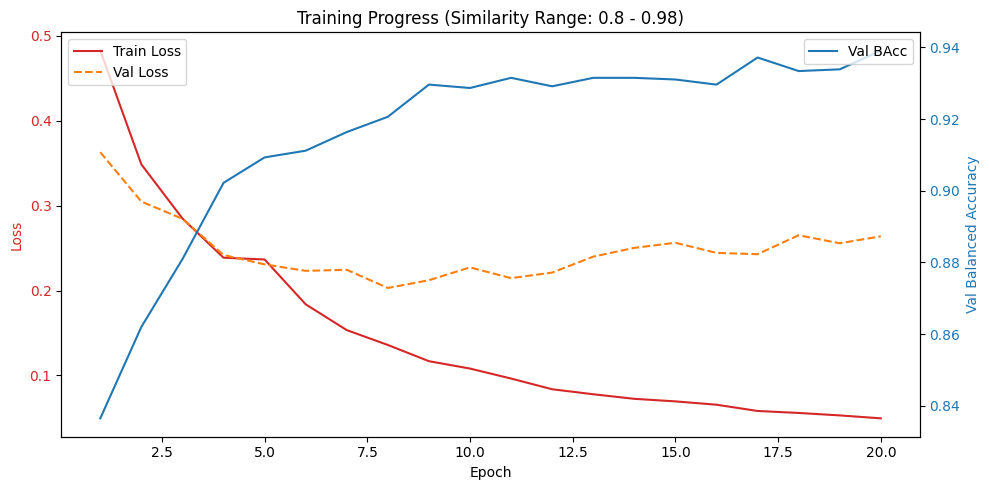

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(1, len(history['train_loss'])+1), history['train_loss'], color='tab:red', label='Train Loss')
ax1.plot(range(1, len(history['val_loss'])+1), history['val_loss'], color='tab:orange', label='Val Loss', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Val Balanced Accuracy', color='tab:blue')
ax2.plot(range(1, len(history['val_bacc'])+1), history['val_bacc'], color='tab:blue', label='Val BAcc')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper right')

plt.title(f'Training Progress (Similarity Range: {MIN_SIM} - {MAX_SIM})')
fig.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.93      0.93      1070
      Simple       0.93      0.92      0.93      1069

    accuracy                           0.93      2139
   macro avg       0.93      0.93      0.93      2139
weighted avg       0.93      0.93      0.93      2139



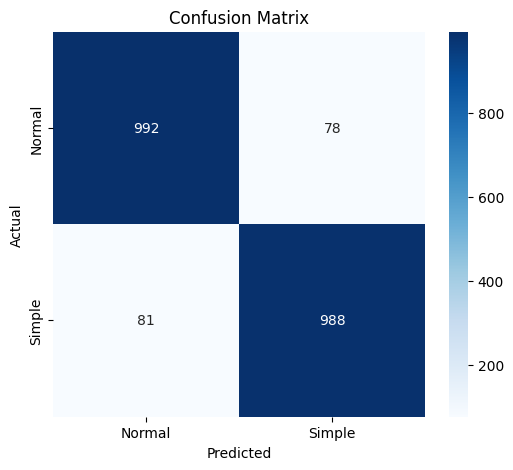

In [6]:
# Finale Evaluation auf dem Test-Set
model.load_state_dict(torch.load(f"../results/best_model_sim_{MIN_SIM}_{MAX_SIM}.pt"))
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        out = model(bx.to(DEVICE)).squeeze()
        test_preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
        test_targets.extend(by.numpy())

print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=["Normal", "Simple"]))

# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Simple"], yticklabels=["Normal", "Simple"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()